# Preferential attachment
Inspirado en el trabajo de Salgado y Caridi (2022)
- Población de Control ($A_{T_1, T_0}$): No miden todas las aristas nuevas a ciegas. Definen un tiempo inicial $T_0$ y un tiempo posterior $T_1$, y extraen la intersección de paquetes presentes en ambos momentos ($P_{T_0} \cap P_{T_1}$). Sólo miden las nuevas conexiones que reciben esos paquetes específicos que sobrevivieron en el intervalo.  
- Distribución Acumulada para Mitigar Ruido: En lugar de intentar ajustar una curva directamente sobre la probabilidad cruda $\Pi_k^i$ (que es muy ruidosa en grados altos), calculan la distribución acumulada $\sum_{k=0}^K \Pi_k^d$. Al graficar esto en escala log-log, la pendiente resultante les permite aislar el exponente $\tau$.  
- Desacople de la Distribución de Grados ($p_k^i$): Saben que un paquete de grado $k$ puede ser elegido más simplemente porque hay muchísimos paquetes con ese grado. Por lo tanto, separan la probabilidad en $\Pi_k^i = p_k^i h_k^i$, donde $p_k^i$ es la distribución de grados de la red. Al aproximar $\Pi_k \sim k^\tau$ y $p_k \sim k^{-\alpha}$, deducen el verdadero exponente de conexión preferencial como $\delta = \tau + \alpha$.  

<>:91: SyntaxWarning: invalid escape sequence '\d'
<>:91: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v5/kbcdcc412tb1kkysqm2lplxm0000gq/T/ipykernel_83777/656708882.py:91: SyntaxWarning: invalid escape sequence '\d'
  color='#8E44AD', linewidth=3, marker='o', markersize=8, label='Delta ($\delta$)')


Calculando evolución del Preferential Attachment para 29 intervalos...



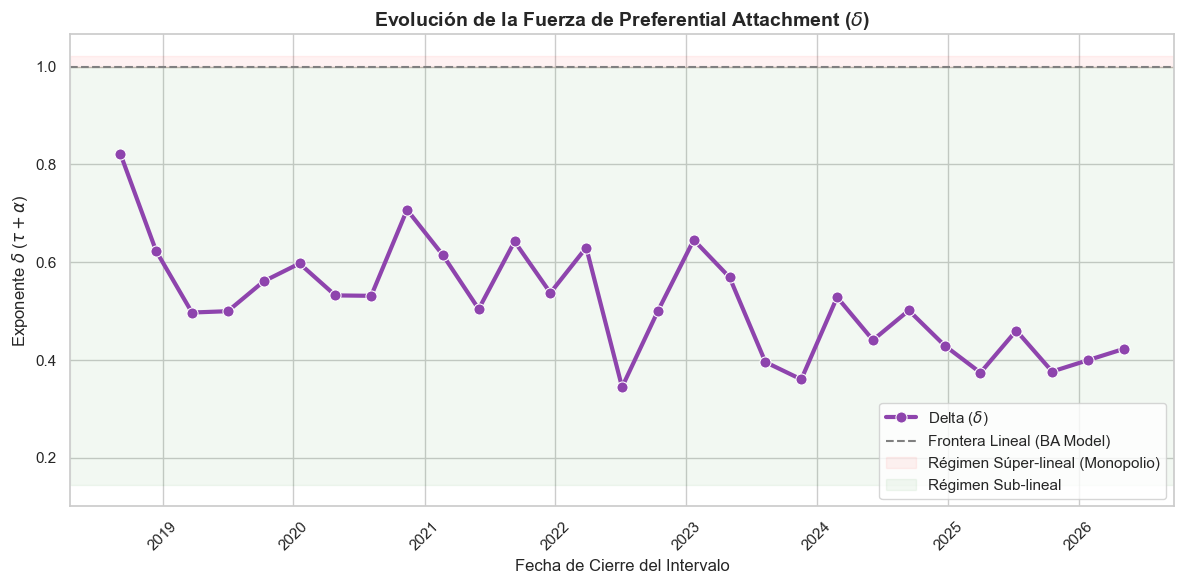

/var/folders/v5/kbcdcc412tb1kkysqm2lplxm0000gq/T/ipykernel_83777/656708882.py:108: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(df_evolution.round(3))


,Ventana,Fecha Final (T1),Alpha (Grados),Tau (Adquisición),Delta,R2_Pk,R2_PiK
0,2018-05-28 -> 2018-09-05,2018-09-05,1.388,-0.566,0.822,0.789,0.810
1,2018-09-05 -> 2018-12-14,2018-12-14,1.335,-0.712,0.623,0.919,0.972
2,2018-12-14 -> 2019-03-24,2019-03-24,1.288,-0.791,0.497,0.811,0.941
3,2019-03-24 -> 2019-07-02,2019-07-02,1.305,-0.805,0.500,0.832,0.865
4,2019-07-02 -> 2019-10-10,2019-10-10,1.307,-0.746,0.561,0.808,0.765
5,2019-10-10 -> 2020-01-18,2020-01-18,1.316,-0.719,0.598,0.793,0.963
6,2020-01-18 -> 2020-04-27,2020-04-27,1.269,-0.736,0.532,0.862,0.898
7,2020-04-27 -> 2020-08-05,2020-08-05,1.295,-0.764,0.531,0.784,0.913
8,2020-08-05 -> 2020-11-13,2020-11-13,1.283,-0.576,0.707,0.792,0.864
9,2020-11-13 -> 2021-02-21,2021-02-21,1.299,-0.684,0.615,0.767,0.936


In [10]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from pathlib import Path
import importlib
import src.preferential_attachment
importlib.reload(src.preferential_attachment)
from src.preferential_attachment import calculate_empirical_preferential_attachment

# --- 1. Configuración de Fechas ---
gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"
target_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")

results_pa = []
print(f"Calculando evolución del Preferential Attachment para {len(target_dates)-1} intervalos...\n")

# --- 2. Iteración por Pares de Snapshots ---
for i in range(len(target_dates) - 1):
    t0 = target_dates[i]
    t1 = target_dates[i+1]
    
    t0_str = t0.strftime('%Y-%m-%d')
    t1_str = t1.strftime('%Y-%m-%d')
    
    file_t0 = gold_dir / f"gold_edges_{t0_str}.parquet"
    file_t1 = gold_dir / f"gold_edges_{t1_str}.parquet"
    
    # Verificamos que ambos archivos del par existan
    if not (file_t0.exists() and file_t1.exists()):
        continue
        
    df_t0 = pd.read_parquet(file_t0)
    df_t1 = pd.read_parquet(file_t1)
    
    G_t0 = nx.from_pandas_edgelist(df_t0, source='source_node', target='target_node', create_using=nx.DiGraph())
    G_t1 = nx.from_pandas_edgelist(df_t1, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    if G_t0.number_of_nodes() == 0 or G_t1.number_of_nodes() == 0:
        continue
        
    # --- 3. Cálculo Empírico ---
    df_att = calculate_empirical_preferential_attachment(G_t0, G_t1)
    
    # Filtro de seguridad: log10(0) y cantidad de puntos para regresión
    df_log = df_att[df_att['k'] > 0].copy()
    mask_cum = df_log['Accumulated_Pi_k'] > 0
    df_log_valid = df_log[mask_cum].copy()
    
    # Si tenemos menos de 3 puntos, la regresión lineal pierde sentido/falla
    if len(df_log_valid) < 3:
        continue
        
    log_k = np.log10(df_log_valid['k'])
    log_pk = np.log10(df_log_valid['p_k'])
    log_cum_pik = np.log10(df_log_valid['Accumulated_Pi_k'])
    
    # --- 4. Ajustes Log-Log ---
    # Pendiente de la distribución de grados (-alpha)
    slope_pk, _, r_pk, _, _ = linregress(log_k, log_pk)
    alpha = -slope_pk
    
    # Pendiente de la adquisición acumulada (tau + 1)
    slope_pik, _, r_pik, _, _ = linregress(log_k, log_cum_pik)
    tau = slope_pik - 1
    
    # Exponente de conexión preferencial (delta)
    delta = tau + alpha
    
    results_pa.append({
        'Ventana': f"{t0_str} -> {t1_str}",
        'Fecha Final (T1)': t1,
        'Alpha (Grados)': alpha,
        'Tau (Adquisición)': tau,
        'Delta': delta,
        'R2_Pk': r_pk**2,
        'R2_PiK': r_pik**2
    })

df_evolution = pd.DataFrame(results_pa)

# --- 5. Visualización de la Dinámica Evolutiva ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# Trazado del Delta a lo largo del tiempo
sns.lineplot(data=df_evolution, x='Fecha Final (T1)', y='Delta', 
             color='#8E44AD', linewidth=3, marker='o', markersize=8, label='Delta ($\delta$)')

# Líneas de referencia para los regímenes de conexión
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Frontera Lineal (BA Model)')
ax.axhspan(1.0, df_evolution['Delta'].max() + 0.2, color='red', alpha=0.05, label='Régimen Súper-lineal (Monopolio)')
ax.axhspan(df_evolution['Delta'].min() - 0.2, 1.0, color='green', alpha=0.05, label='Régimen Sub-lineal')

# Textos crudos con prefijo 'r' para evitar el SyntaxWarning
ax.set_title(r"Evolución de la Fuerza de Preferential Attachment ($\delta$)", fontsize=14, fontweight='bold')
ax.set_ylabel(r"Exponente $\delta$ ($\tau + \alpha$)", fontsize=12)
ax.set_xlabel("Fecha de Cierre del Intervalo", fontsize=12)

ax.legend(loc='lower right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(df_evolution.round(3))

# Verificación
Complementamos los valores de $\delta$ en intervalos de 100 días con:
- valores en rangos más amplios: 500, 1000, 2900.
- cálculo de gini de nuevas conexiones vs conexiones preexistentes

Calculando Macro Preferential Attachment y Dinámica de Gini...



<>:121: SyntaxWarning: invalid escape sequence '\d'
<>:121: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v5/kbcdcc412tb1kkysqm2lplxm0000gq/T/ipykernel_83777/531174624.py:121: SyntaxWarning: invalid escape sequence '\d'
  ax2.plot(x_pos, df_macro['Delta'], color='#E74C3C', marker='o', linewidth=3, markersize=10, label='Exponente Delta ($\delta$)')


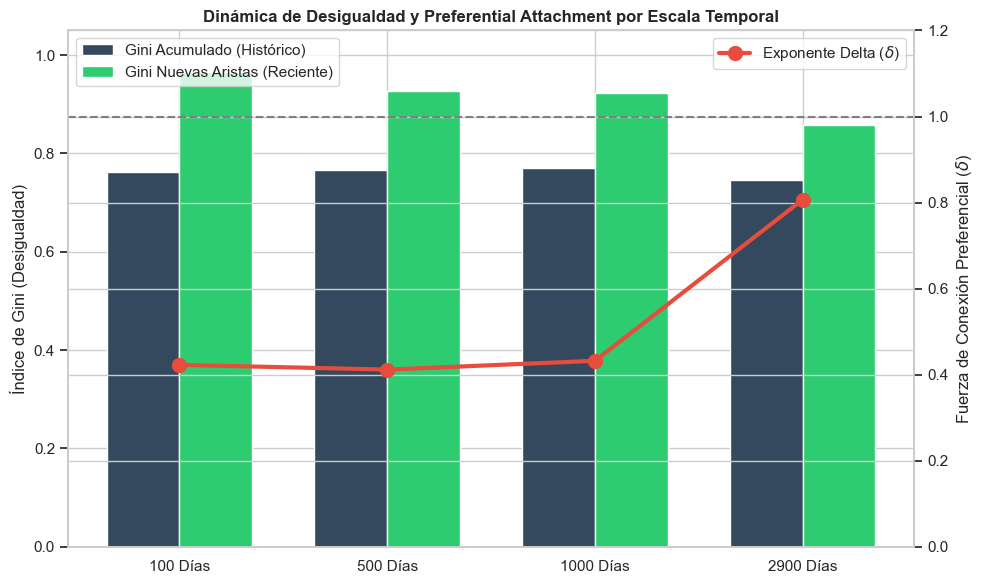

,Ventana,T0,T1,Delta,Gini Acumulado (T0),Gini Nueva Riqueza,Nuevas Conexiones
0,100 Días,2026-01-26,2026-05-06,0.423,0.762,0.966,47
1,500 Días,2024-12-22,2026-05-06,0.412,0.767,0.927,124
2,1000 Días,2023-08-10,2026-05-06,0.432,0.771,0.923,182
3,2900 Días,2018-05-28,2026-05-06,0.807,0.746,0.859,730


In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from pathlib import Path
from collections import Counter

# Importamos tu función de Gini
from src.network_metrics import calculate_gini_index

# (Asumimos calculate_empirical_preferential_attachment ya definida)

# --- 1. Configuración ---
gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"
target_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")

# Definimos los saltos macro: 1 (100d), 5 (500d), 10 (1000d) y 29 (3000d - Salto total)
step_sizes = [1, 5, 10, 29]
results_macro = []

print("Calculando Macro Preferential Attachment y Dinámica de Gini...\n")

# --- 2. Bucle de Procesamiento ---
for step in step_sizes:
    # Para simplificar y comparar manzanas con manzanas, 
    # evaluaremos el salto que termina en el último snapshot disponible.
    t1_idx = len(target_dates) - 1
    t0_idx = t1_idx - step
    
    t0 = target_dates[t0_idx]
    t1 = target_dates[t1_idx]
    
    t0_str = t0.strftime('%Y-%m-%d')
    t1_str = t1.strftime('%Y-%m-%d')
    
    file_t0 = gold_dir / f"gold_edges_{t0_str}.parquet"
    file_t1 = gold_dir / f"gold_edges_{t1_str}.parquet"
    
    if not (file_t0.exists() and file_t1.exists()):
        continue
        
    df_t0 = pd.read_parquet(file_t0)
    df_t1 = pd.read_parquet(file_t1)
    
    G_t0 = nx.from_pandas_edgelist(df_t0, source='source_node', target='target_node', create_using=nx.DiGraph())
    G_t1 = nx.from_pandas_edgelist(df_t1, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    # === A. Cálculo de Delta (PA Empírico) ===
    df_att = calculate_empirical_preferential_attachment(G_t0, G_t1)
    df_log = df_att[df_att['k'] > 0].copy()
    mask_cum = df_log['Accumulated_Pi_k'] > 0
    df_log_valid = df_log[mask_cum].copy()
    
    if len(df_log_valid) >= 3:
        log_k = np.log10(df_log_valid['k'])
        log_pk = np.log10(df_log_valid['p_k'])
        log_cum_pik = np.log10(df_log_valid['Accumulated_Pi_k'])
        
        slope_pk, _, _, _, _ = linregress(log_k, log_pk)
        slope_pik, _, _, _, _ = linregress(log_k, log_cum_pik)
        
        delta = (slope_pik - 1) + (-slope_pk)
    else:
        delta = np.nan
        
    # === B. Cálculo de Gini (Población de Control) ===
    common_nodes = set(G_t0.nodes()) & set(G_t1.nodes())
    new_edges = set(G_t1.edges()) - set(G_t0.edges())
    valid_new_edges = [edge for edge in new_edges if edge[1] in common_nodes]
    
    in_degree_t0 = dict(G_t0.in_degree())
    
    # 1. Riqueza Acumulada
    accumulated_wealth = np.array([in_degree_t0[n] for n in common_nodes])
    
    # 2. Riqueza Nueva (Conexiones recibidas en el intervalo)
    new_wealth_counts = Counter([edge[1] for edge in valid_new_edges])
    new_wealth = np.array([new_wealth_counts.get(n, 0) for n in common_nodes])
    
    gini_accum = calculate_gini_index(accumulated_wealth)
    gini_new = calculate_gini_index(new_wealth)
    
    results_macro.append({
        'Ventana': f"{step * 100} Días",
        'T0': t0_str,
        'T1': t1_str,
        'Delta': delta,
        'Gini Acumulado (T0)': gini_accum,
        'Gini Nueva Riqueza': gini_new,
        'Nuevas Conexiones': len(valid_new_edges)
    })

df_macro = pd.DataFrame(results_macro)

# --- 3. Visualización de Resultados ---
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

x_labels = df_macro['Ventana']
x_pos = np.arange(len(x_labels))
width = 0.35

# Barras de Gini
rects1 = ax1.bar(x_pos - width/2, df_macro['Gini Acumulado (T0)'], width, 
                 label='Gini Acumulado (Histórico)', color='#34495E')
rects2 = ax1.bar(x_pos + width/2, df_macro['Gini Nueva Riqueza'], width, 
                 label='Gini Nuevas Aristas (Reciente)', color='#2ECC71')

ax1.set_ylabel('Índice de Gini (Desigualdad)')
ax1.set_title('Dinámica de Desigualdad y Preferential Attachment por Escala Temporal', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)
ax1.set_ylim(0, 1.05)
ax1.legend(loc='upper left')

# Eje secundario para Delta
ax2 = ax1.twinx()
ax2.plot(x_pos, df_macro['Delta'], color='#E74C3C', marker='o', linewidth=3, markersize=10, label='Exponente Delta ($\delta$)')
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_ylabel(r'Fuerza de Conexión Preferencial ($\delta$)')
ax2.set_ylim(0, max(1.2, df_macro['Delta'].max(skipna=True) + 0.2))
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

display(df_macro.round(3))

Evaluando distribución de nuevas dependencias: 2025-07-10 -> 2026-05-06...



/var/folders/v5/kbcdcc412tb1kkysqm2lplxm0000gq/T/ipykernel_83777/3669203712.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


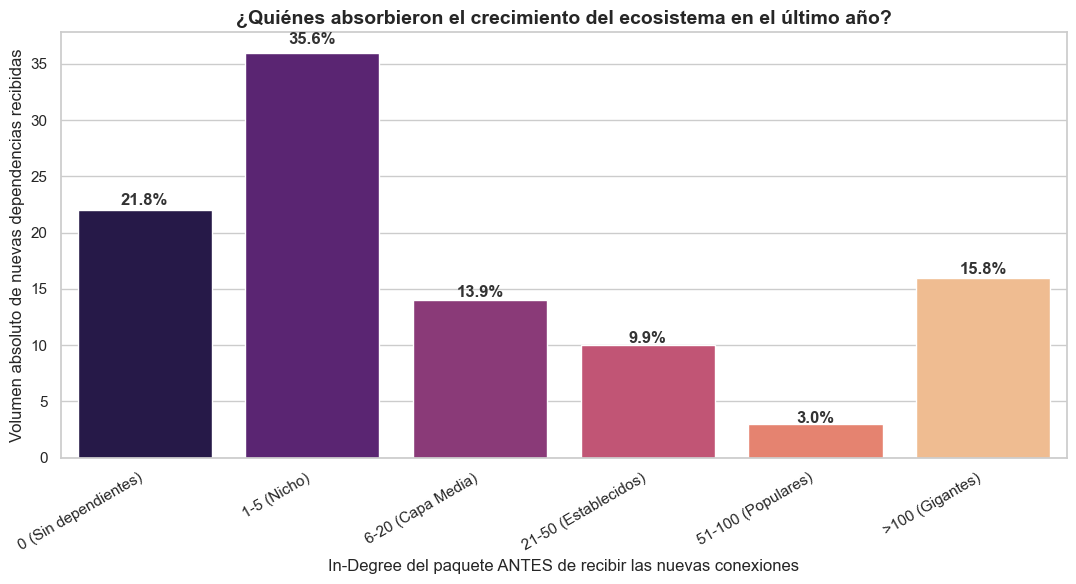

--- DESGLOSE EMPÍRICO DEL CRECIMIENTO ---


,Rango de Popularidad Previa,Nuevas Dependencias Absorbidas,Porcentaje (%)
0,0 (Sin dependientes),22,21.8
1,1-5 (Nicho),36,35.6
2,6-20 (Capa Media),14,13.9
3,21-50 (Establecidos),10,9.9
4,51-100 (Populares),3,3.0
5,>100 (Gigantes),16,15.8


In [7]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# --- 1. Configuración de la Ventana Temporal (Últimos ~300 días) ---
gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"
target_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")

t0_str = target_dates[-4].strftime('%Y-%m-%d')
t1_str = target_dates[-1].strftime('%Y-%m-%d')

print(f"Evaluando distribución de nuevas dependencias: {t0_str} -> {t1_str}...\n")

df_t0 = pd.read_parquet(gold_dir / f"gold_edges_{t0_str}.parquet")
df_t1 = pd.read_parquet(gold_dir / f"gold_edges_{t1_str}.parquet")

G_t0 = nx.from_pandas_edgelist(df_t0, source='source_node', target='target_node', create_using=nx.DiGraph())
G_t1 = nx.from_pandas_edgelist(df_t1, source='source_node', target='target_node', create_using=nx.DiGraph())

# --- 2. Aislamiento de Nuevas Aristas en la Población de Control ---
new_edges = set(G_t1.edges()) - set(G_t0.edges())
common_nodes = set(G_t0.nodes()) & set(G_t1.nodes())
valid_new_edges = [e for e in new_edges if e[1] in common_nodes]

# Obtener el grado previo de los receptores
in_degree_t0 = dict(G_t0.in_degree())
receptor_degrees = [in_degree_t0[edge[1]] for edge in valid_new_edges]

# --- 3. Clasificación en Tiers (Bins) ---
bins = [-1, 0, 5, 20, 50, 100, np.inf]
labels = [
    '0 (Sin dependientes)', 
    '1-5 (Nicho)', 
    '6-20 (Capa Media)', 
    '21-50 (Establecidos)', 
    '51-100 (Populares)', 
    '>100 (Gigantes)'
]

df_receptors = pd.DataFrame({'Grado_T0': receptor_degrees})
df_receptors['Rango'] = pd.cut(df_receptors['Grado_T0'], bins=bins, labels=labels)

# Contabilizar y calcular porcentajes
distribucion = df_receptors['Rango'].value_counts().sort_index().reset_index()
distribucion.columns = ['Rango de Popularidad Previa', 'Nuevas Dependencias Absorbidas']
total_edges = len(valid_new_edges)

if total_edges > 0:
    distribucion['Porcentaje (%)'] = (distribucion['Nuevas Dependencias Absorbidas'] / total_edges * 100).round(1)
else:
    distribucion['Porcentaje (%)'] = 0.0

# --- 4. Visualización Directa ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=distribucion, 
    x='Rango de Popularidad Previa', 
    y='Nuevas Dependencias Absorbidas', 
    palette='magma'
)

plt.title("¿Quiénes absorbieron el crecimiento del ecosistema en el último año?", fontsize=14, fontweight='bold')
plt.xlabel("In-Degree del paquete ANTES de recibir las nuevas conexiones", fontsize=12)
plt.ylabel("Volumen absoluto de nuevas dependencias recibidas", fontsize=12)
plt.xticks(rotation=30, ha='right')

# Etiquetas de porcentaje sobre las barras
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        porcentaje = distribucion['Porcentaje (%)'].iloc[i]
        ax.text(p.get_x() + p.get_width()/2., height + (height * 0.02), f"{porcentaje}%", 
                ha="center", fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

print("--- DESGLOSE EMPÍRICO DEL CRECIMIENTO ---")
display(distribucion)

Evaluando distribución histórica en 10 cortes de ~300 días...



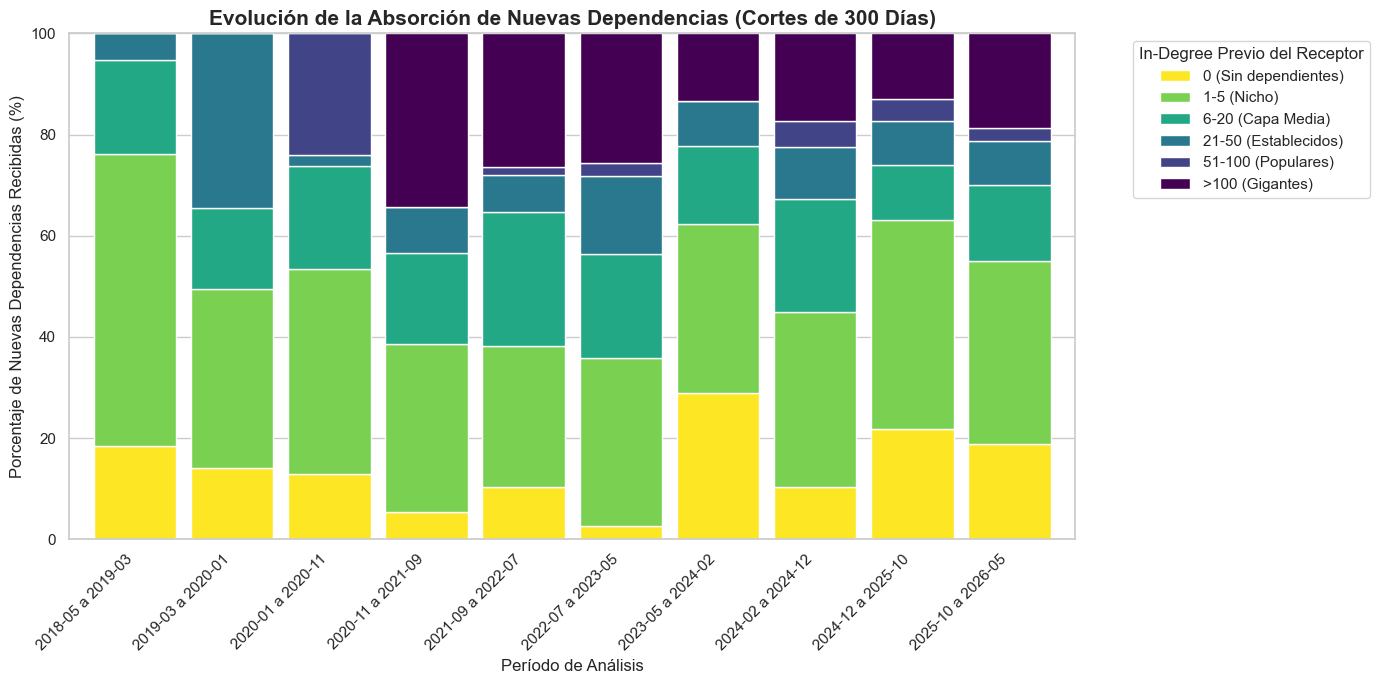

Rango,0 (Sin dependientes),1-5 (Nicho),6-20 (Capa Media),21-50 (Establecidos),51-100 (Populares),>100 (Gigantes)
Ventana,,,,,,
2018-05 a 2019-03,18.5,57.7,18.5,5.4,0.0,0.0
2019-03 a 2020-01,14.0,35.5,15.9,34.6,0.0,0.0
2020-01 a 2020-11,12.9,40.5,20.3,2.2,24.1,0.0
2020-11 a 2021-09,5.4,33.1,18.1,9.0,0.0,34.3
2021-09 a 2022-07,10.3,27.9,26.5,7.4,1.5,26.5
2022-07 a 2023-05,2.6,33.3,20.5,15.4,2.6,25.6
2023-05 a 2024-02,28.9,33.3,15.6,8.9,0.0,13.3
2024-02 a 2024-12,10.3,34.5,22.4,10.3,5.2,17.2
2024-12 a 2025-10,21.7,41.3,10.9,8.7,4.3,13.0


In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# --- 1. Configuración ---
gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"
target_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")

bins = [-1, 0, 5, 20, 50, 100, np.inf]
labels = [
    '0 (Sin dependientes)', 
    '1-5 (Nicho)', 
    '6-20 (Capa Media)', 
    '21-50 (Establecidos)', 
    '51-100 (Populares)', 
    '>100 (Gigantes)'
]

resultados_historicos = []
step = 3 # 300 días (3 * 100 días)

print(f"Evaluando distribución histórica en {len(range(0, len(target_dates)-1, step))} cortes de ~300 días...\n")

# --- 2. Iteración Histórica ---
for i in range(0, len(target_dates) - 1, step):
    t0_idx = i
    t1_idx = min(i + step, len(target_dates) - 1) # Evitar desborde en el último corte
    
    t0 = target_dates[t0_idx]
    t1 = target_dates[t1_idx]
    
    t0_str = t0.strftime('%Y-%m-%d')
    t1_str = t1.strftime('%Y-%m-%d')
    ventana_label = f"{t0.year}-{t0.month:02d} a {t1.year}-{t1.month:02d}"
    
    file_t0 = gold_dir / f"gold_edges_{t0_str}.parquet"
    file_t1 = gold_dir / f"gold_edges_{t1_str}.parquet"
    
    if not (file_t0.exists() and file_t1.exists()):
        continue
        
    df_t0 = pd.read_parquet(file_t0)
    df_t1 = pd.read_parquet(file_t1)
    
    G_t0 = nx.from_pandas_edgelist(df_t0, source='source_node', target='target_node', create_using=nx.DiGraph())
    G_t1 = nx.from_pandas_edgelist(df_t1, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    # Aislamiento de Nuevas Aristas
    new_edges = set(G_t1.edges()) - set(G_t0.edges())
    common_nodes = set(G_t0.nodes()) & set(G_t1.nodes())
    valid_new_edges = [e for e in new_edges if e[1] in common_nodes]
    
    total_edges = len(valid_new_edges)
    if total_edges == 0:
        continue
        
    in_degree_t0 = dict(G_t0.in_degree())
    receptor_degrees = [in_degree_t0[edge[1]] for edge in valid_new_edges]
    
    df_receptors = pd.DataFrame({'Grado_T0': receptor_degrees})
    df_receptors['Rango'] = pd.cut(df_receptors['Grado_T0'], bins=bins, labels=labels)
    
    conteos = df_receptors['Rango'].value_counts()
    
    for rango in labels:
        cantidad = conteos.get(rango, 0)
        porcentaje = (cantidad / total_edges) * 100
        
        resultados_historicos.append({
            'Ventana': ventana_label,
            'Orden': i,
            'Rango': rango,
            'Porcentaje': porcentaje
        })

df_plot = pd.DataFrame(resultados_historicos)

# --- 3. Preparación de Datos para el Gráfico ---
# Pivotamos los datos para tener los rangos como columnas
df_pivot = df_plot.pivot(index='Ventana', columns='Rango', values='Porcentaje').fillna(0)
# Reordenamos las columnas para mantener la jerarquía de los labels
df_pivot = df_pivot[labels]

# --- 4. Visualización (Barras Apiladas 100%) ---
sns.set_theme(style="whitegrid")
ax = df_pivot.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 7), 
    colormap='viridis_r', 
    width=0.85
)

plt.title("Evolución de la Absorción de Nuevas Dependencias (Cortes de 300 Días)", fontsize=15, fontweight='bold')
plt.xlabel("Período de Análisis", fontsize=12)
plt.ylabel("Porcentaje de Nuevas Dependencias Recibidas (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Mover la leyenda afuera para que no tape los datos
plt.legend(title="In-Degree Previo del Receptor", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Mostrar la tabla en crudo como respaldo
display(df_pivot.round(1))

Evaluando absorción por Percentiles en 10 cortes...



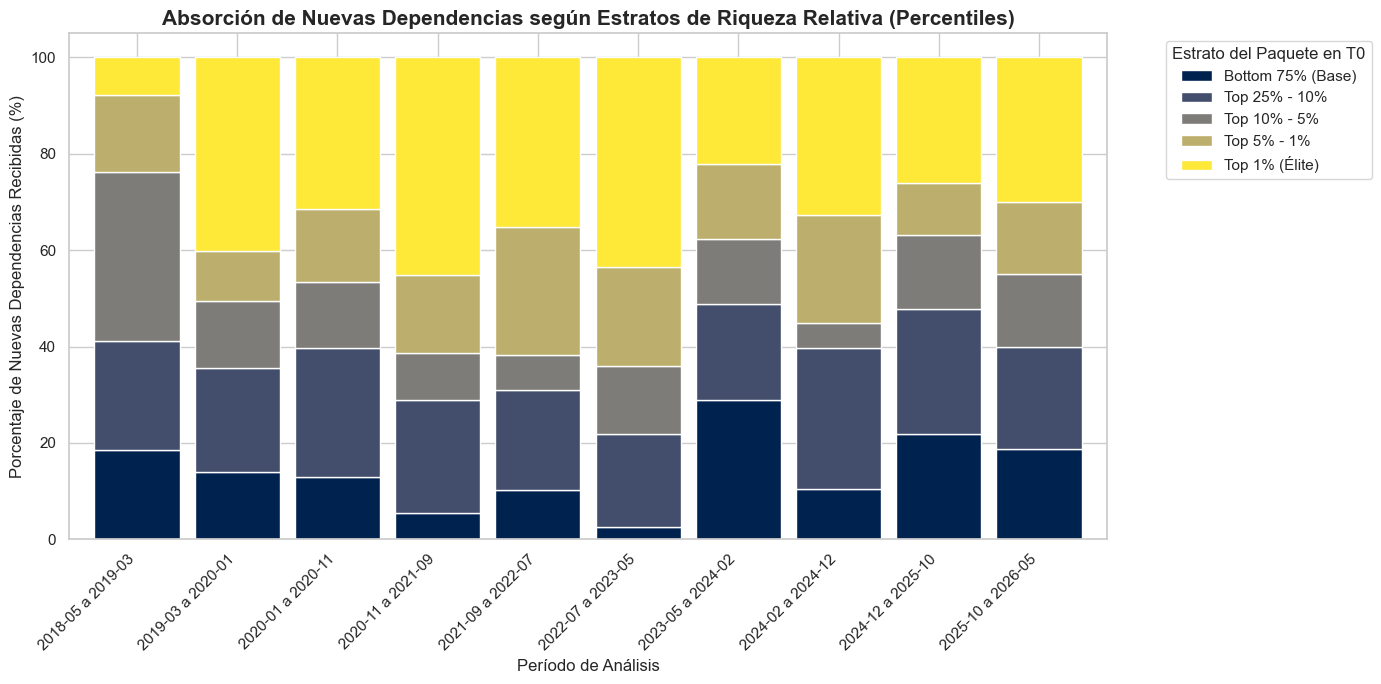

--- DISTRIBUCIÓN PORCENTUAL POR ESTRATOS ---


Estrato (Percentil),Bottom 75% (Base),Top 25% - 10%,Top 10% - 5%,Top 5% - 1%,Top 1% (Élite)
Ventana,,,,,
2018-05 a 2019-03,18.5,22.6,35.1,16.1,7.7
2019-03 a 2020-01,14.0,21.5,14.0,10.3,40.2
2020-01 a 2020-11,12.9,26.7,13.8,15.1,31.5
2020-11 a 2021-09,5.4,23.5,9.6,16.3,45.2
2021-09 a 2022-07,10.3,20.6,7.4,26.5,35.3
2022-07 a 2023-05,2.6,19.2,14.1,20.5,43.6
2023-05 a 2024-02,28.9,20.0,13.3,15.6,22.2
2024-02 a 2024-12,10.3,29.3,5.2,22.4,32.8
2024-12 a 2025-10,21.7,26.1,15.2,10.9,26.1


In [9]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- 1. Configuración ---
gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"
target_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")

# Definimos el orden jerárquico de los estratos para el gráfico
tier_order = [
    'Bottom 75% (Base)', 
    'Top 25% - 10%', 
    'Top 10% - 5%', 
    'Top 5% - 1%', 
    'Top 1% (Élite)'
]

def get_percentile_tier(p):
    """Clasifica un valor de percentil (0.0 a 1.0) en estratos"""
    if p <= 0.75: return 'Bottom 75% (Base)'
    elif p <= 0.90: return 'Top 25% - 10%'
    elif p <= 0.95: return 'Top 10% - 5%'
    elif p <= 0.99: return 'Top 5% - 1%'
    else: return 'Top 1% (Élite)'

resultados_percentiles = []
step = 3 # Cortes de 300 días

print(f"Evaluando absorción por Percentiles en {len(range(0, len(target_dates)-1, step))} cortes...\n")

# --- 2. Iteración Histórica ---
for i in range(0, len(target_dates) - 1, step):
    t0_idx = i
    t1_idx = min(i + step, len(target_dates) - 1)
    
    t0 = target_dates[t0_idx]
    t1 = target_dates[t1_idx]
    
    t0_str = t0.strftime('%Y-%m-%d')
    t1_str = t1.strftime('%Y-%m-%d')
    ventana_label = f"{t0.year}-{t0.month:02d} a {t1.year}-{t1.month:02d}"
    
    file_t0 = gold_dir / f"gold_edges_{t0_str}.parquet"
    file_t1 = gold_dir / f"gold_edges_{t1_str}.parquet"
    
    if not (file_t0.exists() and file_t1.exists()):
        continue
        
    df_t0 = pd.read_parquet(file_t0)
    df_t1 = pd.read_parquet(file_t1)
    
    G_t0 = nx.from_pandas_edgelist(df_t0, source='source_node', target='target_node', create_using=nx.DiGraph())
    G_t1 = nx.from_pandas_edgelist(df_t1, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    common_nodes = set(G_t0.nodes()) & set(G_t1.nodes())
    new_edges = set(G_t1.edges()) - set(G_t0.edges())
    valid_new_edges = [e for e in new_edges if e[1] in common_nodes]
    
    total_edges = len(valid_new_edges)
    if total_edges == 0:
        continue
        
    # --- 3. Estratificación (Ranking Relativo) en T0 ---
    in_degree_t0 = dict(G_t0.in_degree())
    
    # Creamos un DF con toda la población de control para calcular percentiles reales
    df_pop = pd.DataFrame({'node': list(common_nodes)})
    df_pop['in_degree'] = df_pop['node'].map(in_degree_t0)
    
    # rank(pct=True, method='max') asegura que los empates en 0 caigan en el estrato inferior correctamente
    df_pop['percentil'] = df_pop['in_degree'].rank(pct=True, method='max')
    df_pop['Tier'] = df_pop['percentil'].apply(get_percentile_tier)
    
    # --- 4. Cruce de Nuevas Aristas con los Estratos ---
    receptors = [e[1] for e in valid_new_edges]
    df_receptors = pd.DataFrame({'node': receptors})
    
    # Unimos los receptores con su tier calculado en T0
    df_merged = df_receptors.merge(df_pop[['node', 'Tier']], on='node', how='left')
    conteos = df_merged['Tier'].value_counts()
    
    for tier in tier_order:
        cantidad = conteos.get(tier, 0)
        porcentaje = (cantidad / total_edges) * 100
        
        resultados_percentiles.append({
            'Ventana': ventana_label,
            'Estrato (Percentil)': tier,
            'Porcentaje': porcentaje
        })

df_plot = pd.DataFrame(resultados_percentiles)

# --- 5. Preparación de Datos para el Gráfico ---
df_pivot = df_plot.pivot(index='Ventana', columns='Estrato (Percentil)', values='Porcentaje').fillna(0)
df_pivot = df_pivot[tier_order]

# --- 6. Visualización ---
sns.set_theme(style="whitegrid")
ax = df_pivot.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 7), 
    colormap='cividis', # Paleta de contrastes fuertes ideal para estratos
    width=0.85
)

plt.title("Absorción de Nuevas Dependencias según Estratos de Riqueza Relativa (Percentiles)", fontsize=15, fontweight='bold')
plt.xlabel("Período de Análisis", fontsize=12)
plt.ylabel("Porcentaje de Nuevas Dependencias Recibidas (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.legend(title="Estrato del Paquete en T0", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Tabla en crudo
print("--- DISTRIBUCIÓN PORCENTUAL POR ESTRATOS ---")
display(df_pivot.round(1))